# Fouls & yellow cards vs game-time heat unusualness — box-and-whisker
Distribution of match fouls / yellow cards by how much of the game window exceeded the local diurnal **1960–1990** climatology (p75 / p90 / p95 / record). Games are grouped into **none (0 %)**, **partial (1–99 %)**, **all (100 %)** of window hours over the level; at each group a **dual box-and-whisker** shows men vs women (no regression line). Sample: StatsBomb complete tournaments — men 2018/22 + women 2019/23.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# set ROOT to the bundle path if you move this notebook
ROOT = "/glade/derecho/scratch/gavinmad/shared/Heathack"
PROC = os.path.join(ROOT, "data", "processed")
plt.rcParams.update({"font.size": 13, "figure.dpi": 120})
d = pd.read_csv(os.path.join(ROOT, "data/interim/outcomes_vs_climpct.csv"))
COL = {"men": "#1f77b4", "women": "#e377c2"}
CATS = ["none (0%)", "partial (1–99%)", "all (100%)"]
def cat(v):
    return np.where(v < 0.5, CATS[0], np.where(v > 99.5, CATS[2], CATS[1]))
# each level = a "how unusual" bar: exceeding pXX = hotter than XX% of the 1960-1990 hours at that stadium/hour/day
LEVELS = [("pct_p75", "p75", "hotter than 75% of 1960–1990"),
          ("pct_p90", "p90", "hotter than 90% of 1960–1990"),
          ("pct_p95", "p95", "hotter than 95% of 1960–1990"),
          ("pct_max", "record", "hotter than the 1960–1990 record")]

In [ ]:
# Yellow card figure below is crude, not sure there is a signal there

wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/08_discipline/fouls_p99_boxwhisker.png


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/08_discipline/fouls_max_boxwhisker.png


wrote /glade/derecho/scratch/gavinmad/shared/Heathack/figures/08_discipline/yellow_boxwhisker.png


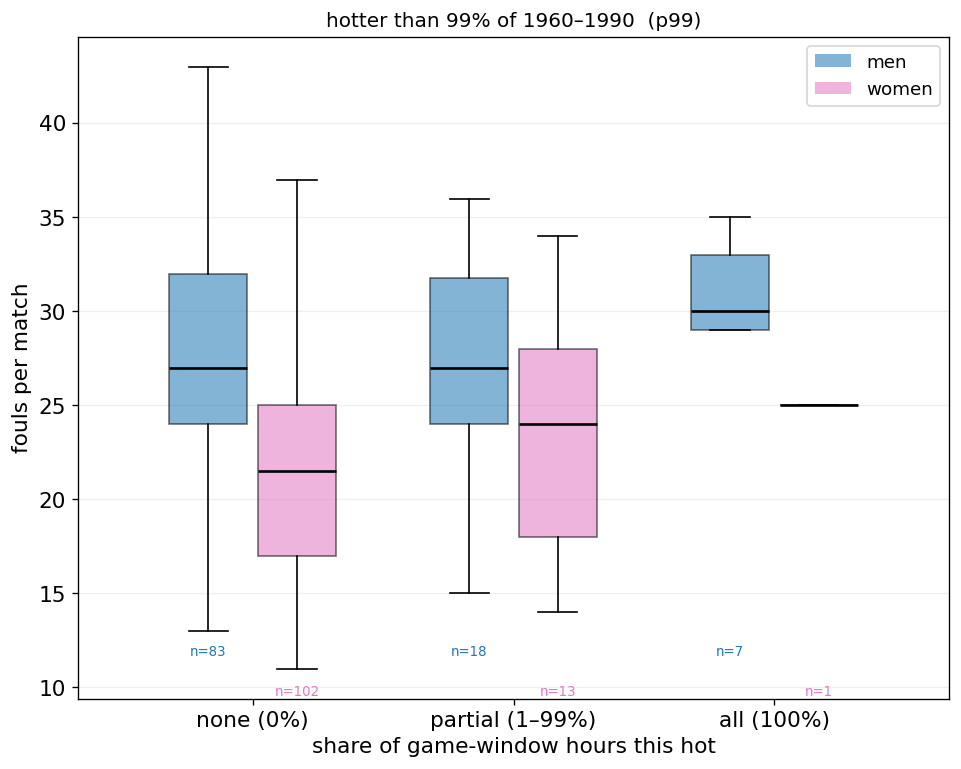

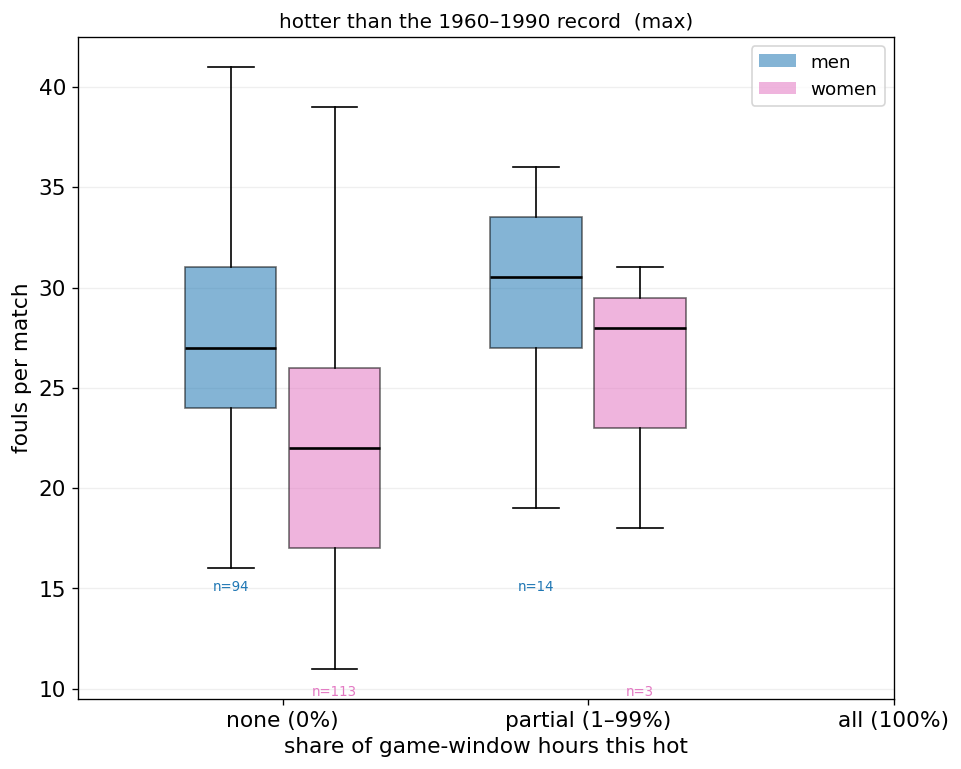

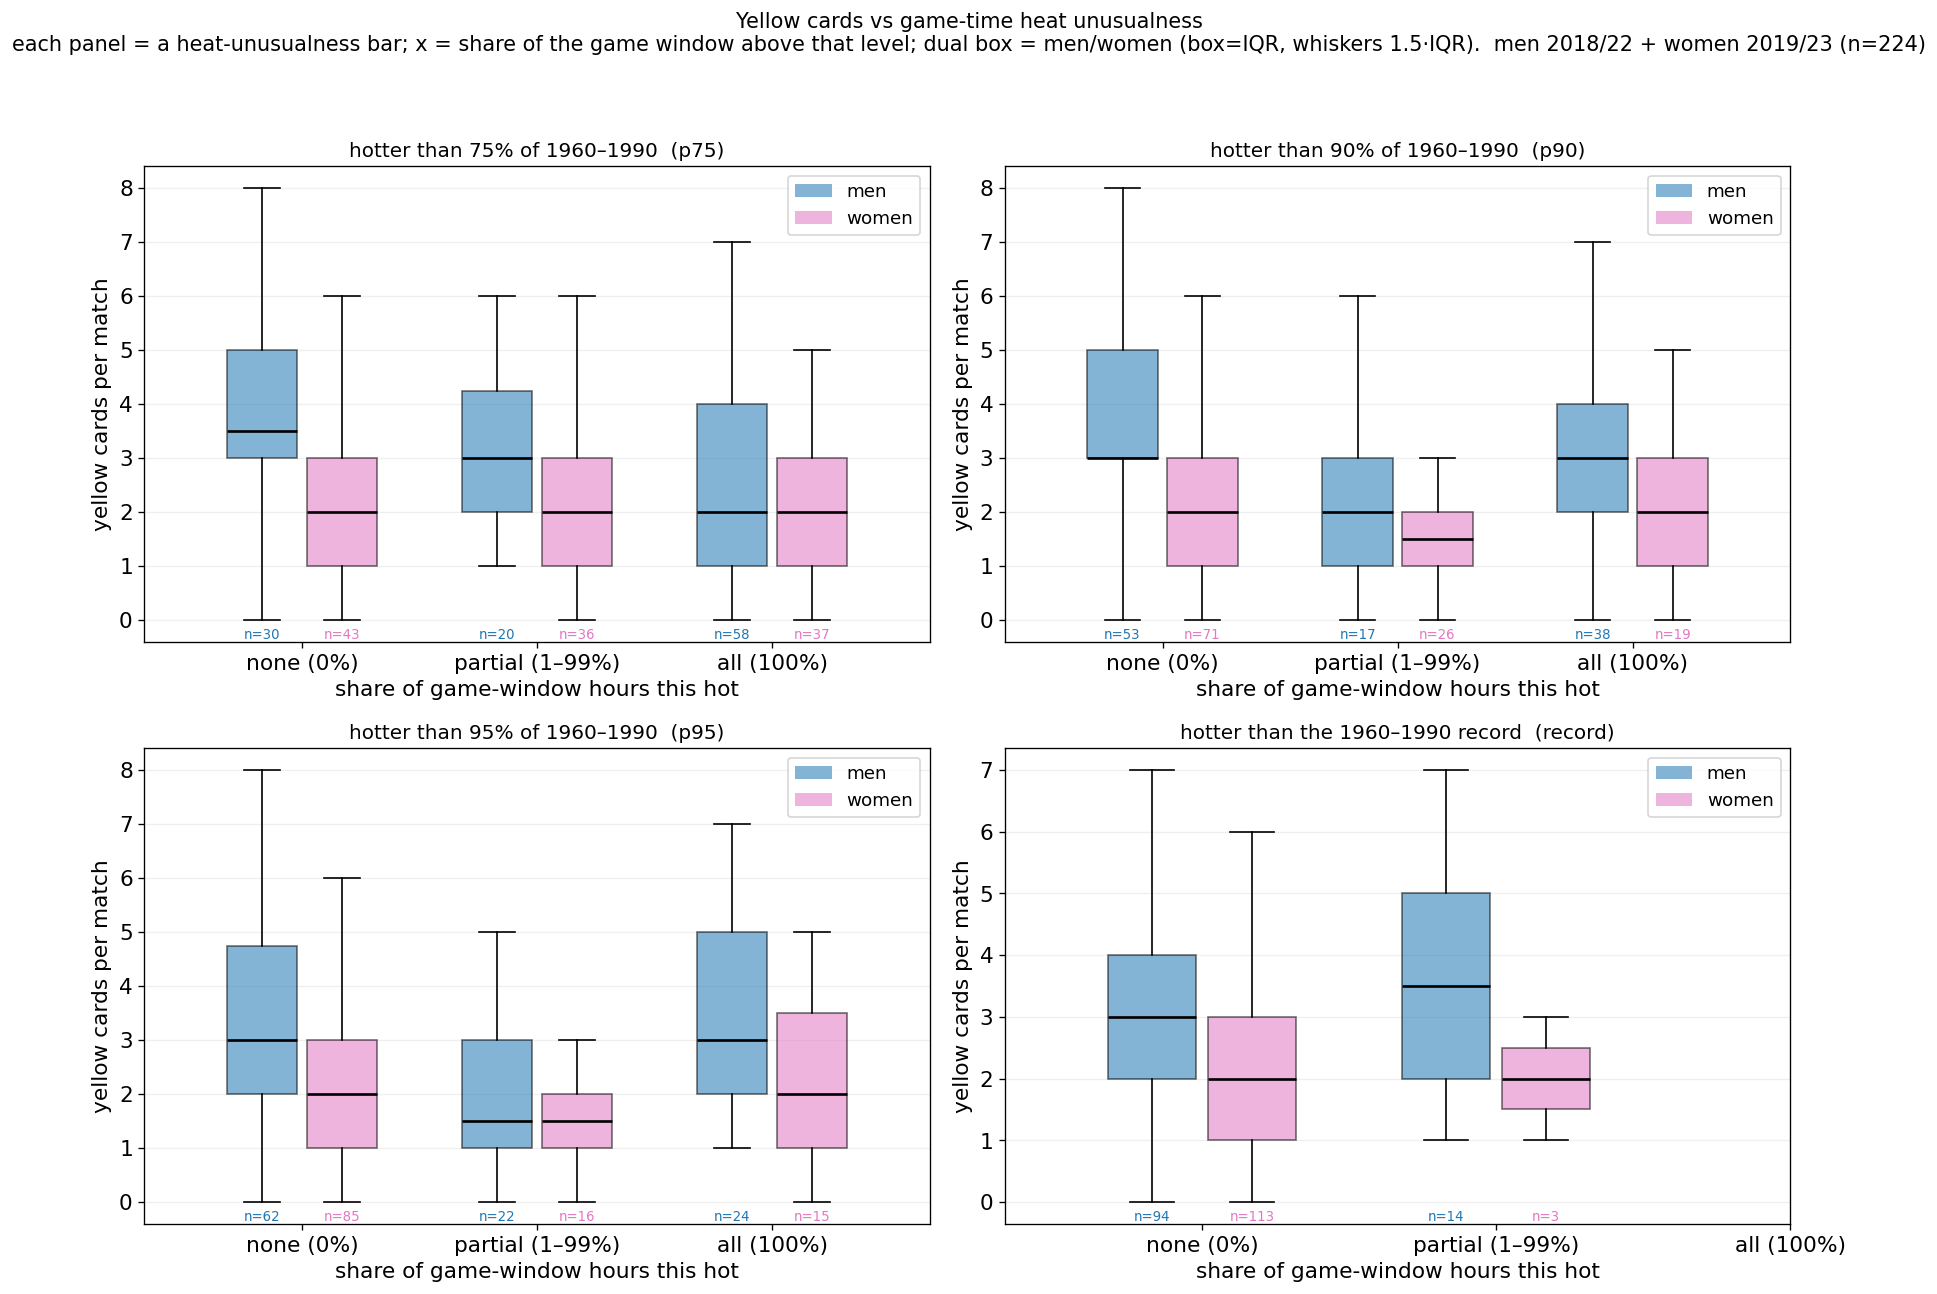

In [2]:
def boxwhisker(ycol, ylab, title, save, levels=LEVELS, suptitle=True):
    if len(levels) == 1:
        fig, ax0 = plt.subplots(figsize=(8.2, 6.6)); axlist = [ax0]
    else:
        fig, axes = plt.subplots(2, 2, figsize=(15, 11)); axlist = list(axes.ravel())
    for ax, (xcol, lab, desc) in zip(axlist, levels):
        dd = d.assign(cat=cat(d[xcol].values))
        handles = []
        for gi, g in enumerate(["men", "women"]):
            data, pos, ns = [], [], []
            for ci, cc in enumerate(CATS):
                v = dd[(dd.gender == g) & (dd.cat == cc)][ycol].values
                if len(v):
                    data.append(v); pos.append(ci + (gi - 0.5) * 0.34); ns.append((ci + (gi - 0.5) * 0.34, len(v)))
            bp = ax.boxplot(data, positions=pos, widths=0.3, patch_artist=True, showfliers=False,
                            medianprops=dict(color="black", lw=1.6))
            for b in bp["boxes"]:
                b.set(facecolor=COL[g], alpha=0.55)
            for xp, n in ns:
                ax.text(xp, ax.get_ylim()[0], f"n={n}", ha="center", va="bottom", fontsize=8, color=COL[g])
            handles.append(Patch(facecolor=COL[g], alpha=0.55, label=g))
        ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS)
        ax.set_xlabel("share of game-window hours this hot"); ax.set_ylabel(ylab)
        ax.set_title(f"{desc}  ({lab})", fontsize=12); ax.legend(handles=handles, fontsize=11)
        ax.grid(alpha=0.2, axis="y")
    if suptitle:
        fig.suptitle(f"{title}\n"
                     f"each panel = a heat-unusualness bar; x = share of the game window above that level; "
                     f"dual box = men/women (box=IQR, whiskers 1.5·IQR).  men 2018/22 + women 2019/23 (n={len(d)})",
                     fontsize=12.5)
    fig.tight_layout(rect=[0, 0, 1, 0.95] if suptitle else [0, 0, 1, 1])
    out = os.path.join(ROOT, f"figures/08_discipline/{save}_boxwhisker.png")
    fig.savefig(out, dpi=160, bbox_inches="tight"); print("wrote", out)

# fouls: single-panel versions at the extreme tail (99th / record), no long title
for tag, lv, q in [("fouls_p99", "p99", 99), ("fouls_max", "max", None)]:
    desc = "hotter than the 1960–1990 record" if q is None else f"hotter than {q}% of 1960–1990"
    boxwhisker("fouls", "fouls per match", "Fouls vs game-time heat unusualness", tag,
               levels=[(f"pct_{lv}", lv, desc)], suptitle=False)
# yellow: full four-panel
boxwhisker("yellow", "yellow cards per match", "Yellow cards vs game-time heat unusualness", "yellow")